# Task 4 (Player Style) — Preprocessing: Unscaled / StandardScaler / RobustScaler

**Input:** `player_style_features_pl_laliga_seriea_1516.csv` (output Task 1, 1016 cầu thủ) + phát hiện từ Task 2/3.

**Khác biệt so với Task 4 ở bài Shot Zone:**
- Không có vấn đề dư thừa thông tin cần loại feature (Task 3 mục 3.2 đã xác nhận không có cặp nào tương quan > 0.9) → **giữ nguyên cả 29 feature**.
- Không có biến categorical cần one-hot (toàn bộ X là numeric per-90/tỷ lệ/toạ độ) → bỏ qua bước encode.
- **Có missing value mang ý nghĩa cấu trúc** (khác bài Shot Zone vốn không có missing trong X) — cần xử lý impute trước khi scale.


## 4.0 — Setup

In [35]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

CSV_PATH = "/kaggle/working/player_style_features_pl_laliga_seriea_1516.csv"
OUT_DIR = "/kaggle/working"

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df.shape


(1016, 36)

## 4.1 — Chốt danh sách feature X & tách 3 nhóm cột

| Nhóm | Cột |
|---|---|
| **ID / định danh** | `player_id`, `player_name`, `primary_team`, `competitions_played`, `n_matches_played`, `total_minutes_played` |
| **X — 29 feature đưa vào K-Means** | toàn bộ feature per-90/tỷ lệ/toạ độ đã trích ở Task 1 |
| **Y_hidden — giấu để validate cụm ở Task 6** | `primary_position` |


In [36]:
id_cols = ["player_id", "player_name", "primary_team", "competitions_played",
           "n_matches_played", "total_minutes_played"]

feature_cols = [
    "shots_p90", "np_goals_p90", "avg_shot_distance", "dribbles_p90", "dribble_success_rate",
    "touches_p90", "touches_in_box_p90", "passes_p90", "pass_completion_pct", "key_passes_p90",
    "assists_p90", "crosses_p90", "through_balls_p90", "long_balls_p90", "avg_pass_length",
    "pressures_p90", "tackles_p90", "tackle_success_rate", "interceptions_p90",
    "interception_success_rate", "ball_recoveries_p90", "clearances_p90", "aerial_won_p90",
    "fouls_committed_p90", "fouls_won_p90", "avg_location_x", "avg_location_y",
    "std_location_x", "std_location_y",
]

hidden_cols = ["primary_position"]

all_used = id_cols + feature_cols + hidden_cols
missing_in_df = [c for c in all_used if c not in df.columns]
assert not missing_in_df, f"Các cột sau không tồn tại: {missing_in_df}"
print(f"Số feature X: {len(feature_cols)}")


Số feature X: 29


## 4.2 — Xử lý missing value (bước mới so với bài Shot Zone)

4 cột bị thiếu đều là **tỷ lệ thành công có điều kiện** hoặc **trung bình có điều kiện** — `NaN` khi cầu thủ chưa từng thực hiện hành động đó. Ví dụ một trung phong hầu như không tắc bóng thì `tackles_p90 = 0` (giá trị thật, không thiếu) nhưng `tackle_success_rate = NaN` (không có lần nào để tính tỷ lệ).

**Cách xử lý:** impute bằng **median toàn cục** của từng cột (không dùng 0, vì 0% thành công mang nghĩa "luôn thất bại" — sai lệch hoàn toàn so với "chưa từng thử"). Vì các cầu thủ này đã có `..._p90` tương ứng gần 0 rồi (đã tự nhiên phản ánh "không phải sở trường"), gán giá trị trung vị cho tỷ lệ thành công là lựa chọn trung tính, không tạo tín hiệu giả cực đoan theo bất kỳ hướng nào.

In [37]:
missing_before = df[feature_cols].isna().sum()
print("Missing trước khi impute:")
print(missing_before[missing_before > 0])

X_raw = df[feature_cols].copy()
impute_values = {}
for col in feature_cols:
    if X_raw[col].isna().any():
        median_val = X_raw[col].median()
        impute_values[col] = median_val
        X_raw[col] = X_raw[col].fillna(median_val)

print("\nGiá trị median dùng để impute:")
for col, val in impute_values.items():
    print(f"  {col}: {val:.4f}")

print("\nMissing sau khi impute:", X_raw.isna().sum().sum())


Missing trước khi impute:
avg_shot_distance            75
dribble_success_rate         42
tackle_success_rate          70
interception_success_rate    72
dtype: int64

Giá trị median dùng để impute:
  avg_shot_distance: 19.7162
  dribble_success_rate: 0.5833
  tackle_success_rate: 0.6087
  interception_success_rate: 0.6187

Missing sau khi impute: 0


## 4.3 — Xây 3 phiên bản: Unscaled / StandardScaler / RobustScaler

In [38]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_unscaled = X_raw.copy()

X_standard = pd.DataFrame(
    standard_scaler.fit_transform(X_raw), columns=feature_cols, index=X_raw.index,
)

X_robust = pd.DataFrame(
    robust_scaler.fit_transform(X_raw), columns=feature_cols, index=X_raw.index,
)

print("X_unscaled:", X_unscaled.shape)
print("X_standard:", X_standard.shape)
print("X_robust  :", X_robust.shape)


X_unscaled: (1016, 29)
X_standard: (1016, 29)
X_robust  : (1016, 29)


## 4.4 — So sánh định lượng: bảng mean/std/min/max

In [39]:
def summarize(X, label):
    s = X.describe().T[["mean", "std", "min", "max"]]
    s.columns = pd.MultiIndex.from_product([[label], s.columns])
    return s

comparison = pd.concat(
    [summarize(X_unscaled, "Unscaled"), summarize(X_standard, "StandardScaler"), summarize(X_robust, "RobustScaler")],
    axis=1,
)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
comparison


Unscaled                       StandardScaler        \
                              mean    std    min     max           mean   std   
shots_p90                    1.162  1.015  0.000   6.268         -0.000 1.000   
np_goals_p90                 0.108  0.147  0.000   1.076         -0.000 1.000   
avg_shot_distance           19.453  5.219  5.431  35.496         -0.000 1.000   
dribbles_p90                 1.608  1.416  0.000   7.852         -0.000 1.000   
dribble_success_rate         0.610  0.174  0.000   1.000          0.000 1.000   
touches_p90                127.726 35.303 49.315 305.988          0.000 1.000   
touches_in_box_p90           5.075  5.248  0.000  30.176         -0.000 1.000   
passes_p90                  42.383 13.541 14.100 113.332         -0.000 1.000   
pass_completion_pct          0.750  0.085  0.391   0.917         -0.000 1.000   
key_passes_p90               0.746  0.604  0.000   3.542         -0.000 1.000   
assists_p90                  0.078  0.093  0.000   0.561          0.000 1.000   
crosses_p90                  1.163  1.180  0.000   6.422          0.000 1.000   
through_balls_p90            0.189  0.233  0.000   3.438          0.000 1.000   
long_balls_p90               8.699  5.200  0.684  29.795         -0.000 1.000   
avg_pass_length             21.673  8.264 11.668  63.403          0.000 1.000   
pressures_p90               14.235  6.539  0.000  40.177          0.000 1.000   
tackles_p90                  1.739  0.962  0.000   4.658          0.000 1.000   
tackle_success_rate          0.608  0.105  0.111   1.000          0.000 1.000   
interceptions_p90            1.136  0.734  0.000   3.539         -0.000 1.000   
interception_success_rate    0.619  0.135  0.000   1.000          0.000 1.000   
ball_recoveries_p90          4.628  1.391  1.315   9.624          0.000 1.000   
clearances_p90               2.134  2.011  0.000  10.265          0.000 1.000   
aerial_won_p90               1.899  1.490  0.000  12.707          0.000 1.000   
fouls_committed_p90          1.366  0.722  0.000   4.333         -0.000 1.000   
fouls_won_p90                1.296  0.861  0.000   5.872         -0.000 1.000   
avg_location_x              59.230 18.870  7.195  87.325          0.000 1.000   
avg_location_y              39.937 14.048  8.969  72.000         -0.000 1.000   
std_location_x              21.865  5.051  5.111  31.967         -0.000 1.000   
std_location_y              17.663  5.331  6.444  31.963          0.000 1.000   

                                        RobustScaler                      
                             min    max         mean   std    min    max  
shots_p90                 -1.145  5.033        0.239 0.704 -0.566  3.779  
np_goals_p90              -0.734  6.568        0.327 0.988 -0.397  6.810  
avg_shot_distance         -2.688  3.076       -0.037 0.741 -2.028  2.240  
dribbles_p90              -1.136  4.411        0.195 0.781 -0.691  3.637  
dribble_success_rate      -3.510  2.242        0.139 0.903 -3.028  2.163  
touches_p90               -2.222  5.052        0.040 0.777 -1.685  3.962  
touches_in_box_p90        -0.967  4.785        0.371 0.880 -0.480  4.579  
passes_p90                -2.090  5.242        0.015 0.719 -1.487  3.782  
pass_completion_pct       -4.214  1.958       -0.088 0.790 -3.416  1.458  
key_passes_p90            -1.237  4.635        0.095 0.707 -0.779  3.370  
assists_p90               -0.841  5.202        0.213 0.766 -0.432  4.197  
crosses_p90               -0.986  4.460        0.211 0.686 -0.466  3.269  
through_balls_p90         -0.813 13.941        0.291 1.025 -0.542 14.566  
long_balls_p90            -1.542  4.059        0.105 0.937 -1.339  3.907  
avg_pass_length           -1.211  5.052        0.366 1.643 -1.623  8.662  
pressures_p90             -2.178  3.969       -0.024 0.785 -1.732  3.089  
tackles_p90               -1.808  3.035        0.051 0.739 -1.283  2.292  
tackle_success_rate       -4.740  3.732       -0.002 0.866 -4.105  3.228  
interceptions_

## 4.5 — Điểm khác biệt thú vị so với bài Shot Zone: RobustScaler KHÔNG phải lúc nào cũng "hiền" hơn

Ở bài Shot Zone, `RobustScaler` xử lý êm cột one-hot hiếm (`body_part_Other`) vì IQR=0. Ở dữ liệu cầu thủ này **không có cột nào IQR=0** (toàn bộ đều là tỷ lệ liên tục, không phải one-hot), nên tình huống khác hẳn. Kiểm tra cụ thể với `np_goals_p90` và `through_balls_p90` — 2 feature có skewness rất cao (đã thấy ở Task 2/3).

In [40]:
check_cols = ["np_goals_p90", "through_balls_p90"]

for col in check_cols:
    print(f"{col}:")
    print(f"  Unscaled       max = {X_unscaled[col].max():.3f}")
    print(f"  StandardScaler max = {X_standard[col].max():.3f}")
    print(f"  RobustScaler   max = {X_robust[col].max():.3f}")
    print()


np_goals_p90:
  Unscaled       max = 1.076
  StandardScaler max = 6.568
  RobustScaler   max = 6.810

through_balls_p90:
  Unscaled       max = 3.438
  StandardScaler max = 13.941
  RobustScaler   max = 14.566



**Kết quả:** với 2 feature lệch phải mạnh này, **RobustScaler cho giá trị max còn cao hơn cả StandardScaler** (ví dụ `np_goals_p90` max ≈6.6 ở StandardScaler nhưng ≈6.8 ở RobustScaler). Lý do: với phân phối tập trung dày đặc gần 0 (đa số cầu thủ ghi rất ít bàn), khoảng IQR (Q3−Q1) lại rất nhỏ hơn cả độ lệch chuẩn — chia cho một mẫu số nhỏ hơn khiến giá trị cực đại (Ronaldo/Messi) bị đẩy lên còn mạnh hơn.

**Bài học quan trọng:** RobustScaler không phải "luôn luôn hiền hơn StandardScaler với outlier" một cách tuyệt đối — nó chỉ ổn định hơn trong tình huống cụ thể ở bài Shot Zone (cột one-hot cực kỳ mất cân bằng, IQR=0). Với **feature liên tục lệch phải mạnh nhưng không có IQR=0** như ở đây, cả 2 scaler đều khuếch đại outlier tương đối giống nhau, thậm chí RobustScaler có thể mạnh tay hơn. Đây là lý do vì sao project vẫn cần **thử nghiệm cả 2 scaler thay vì mặc định tin theo lý thuyết chung chung** — hiệu ứng thực tế phụ thuộc vào hình dạng phân phối cụ thể của từng bộ dữ liệu.

## 4.6 — Trực quan hóa: Box Plot so sánh 3 phiên bản

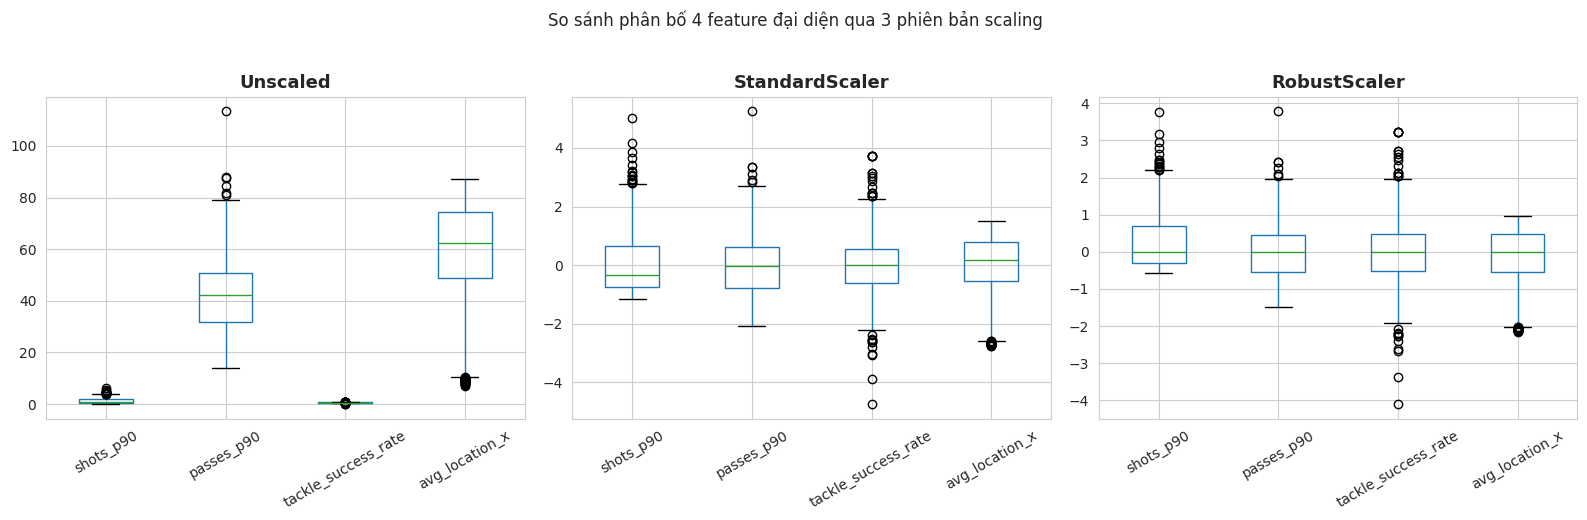

In [41]:
sample_cols = ["shots_p90", "passes_p90", "tackle_success_rate", "avg_location_x"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (X, label) in zip(
    axes, [(X_unscaled, "Unscaled"), (X_standard, "StandardScaler"), (X_robust, "RobustScaler")]
):
    X[sample_cols].boxplot(ax=ax, rot=30)
    ax.set_title(label)

plt.suptitle("So sánh phân bố 4 feature đại diện qua 3 phiên bản scaling", y=1.03)
plt.tight_layout()
plt.show()


## 4.7 — Lưu 3 phiên bản X + file Y_hidden

In [42]:
def build_output(X, id_df):
    return pd.concat([id_df.reset_index(drop=True), X.reset_index(drop=True)], axis=1)


id_df = df[id_cols].copy()
hidden_df = pd.concat([id_df.reset_index(drop=True), df[hidden_cols].reset_index(drop=True)], axis=1)

out_unscaled = build_output(X_unscaled, id_df)
out_standard = build_output(X_standard, id_df)
out_robust = build_output(X_robust, id_df)

out_unscaled.to_csv(f"{OUT_DIR}/player_X_unscaled.csv", index=False, encoding="utf-8-sig")
out_standard.to_csv(f"{OUT_DIR}/player_X_standard_scaled.csv", index=False, encoding="utf-8-sig")
out_robust.to_csv(f"{OUT_DIR}/player_X_robust_scaled.csv", index=False, encoding="utf-8-sig")
hidden_df.to_csv(f"{OUT_DIR}/player_y_hidden.csv", index=False, encoding="utf-8-sig")

print("Đã lưu 4 file:")
for fname in ["player_X_unscaled.csv", "player_X_standard_scaled.csv", "player_X_robust_scaled.csv", "player_y_hidden.csv"]:
    print(" -", f"{OUT_DIR}/{fname}")


Đã lưu 4 file:
 - /kaggle/working/player_X_unscaled.csv
 - /kaggle/working/player_X_standard_scaled.csv
 - /kaggle/working/player_X_robust_scaled.csv
 - /kaggle/working/player_y_hidden.csv


In [43]:
check = pd.read_csv(f"{OUT_DIR}/player_X_standard_scaled.csv", encoding="utf-8-sig")
check.head(3)


,player_id,player_name,primary_team,competitions_played,n_matches_played,total_minutes_played,shots_p90,np_goals_p90,avg_shot_distance,dribbles_p90,...,interception_success_rate,ball_recoveries_p90,clearances_p90,aerial_won_p90,fouls_committed_p90,fouls_won_p90,avg_location_x,avg_location_y,std_location_x,std_location_y
0,3339,Asmir Begović,Chelsea,Premier League,17,1472.000,-1.145,-0.734,0.051,-1.136,...,-0.004,-0.910,-1.062,-1.275,-1.894,-1.221,-2.632,0.017,-3.136,-1.845
1,5594,Branislav Ivanović,Chelsea,Premier League,33,3057.000,-0.332,-0.334,-0.095,-0.762,...,-1.050,-0.766,0.857,0.603,-0.302,-0.685,0.044,1.398,1.102,0.519
2,3456,Kurt Happy Zouma,Chelsea,Premier League,23,2013.000,-0.440,-0.430,-0.487,-0.883,...,-2.114,-1.624,2.698,1.397,-1.274,-1.038,-0.950,0.919,0.009,-0.883


## Kết quả Task 4 (Player Style)

4 file sẵn sàng cho **Task 5 — K-Means → validate bằng `primary_position`**:

| File | Nội dung |
|---|---|
| `player_X_unscaled.csv` | ID + 29 feature gốc (đã impute missing bằng median) |
| `player_X_standard_scaled.csv` | ID + feature đã qua `StandardScaler` |
| `player_X_robust_scaled.csv` | ID + feature đã qua `RobustScaler` |
| `player_y_hidden.csv` | ID + `primary_position` (KHÔNG đưa vào K-Means, chỉ dùng validate) |

Khác với bài Shot Zone, lần này Task 3 đã xác nhận **không cần loại feature nào** — cả 29 feature đều được giữ nguyên qua cả 3 phiên bản.
